In [21]:
import torch.nn as nn
import torch
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split


In [22]:
data = pd.read_csv("Pokemon.csv")
data.head(50)

,#,Name,Type 1,Type 2,Total,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation,Legendary
0,1,Bulbasaur,Grass,Poison,318,45,49,49,65,65,45,1,False
1,2,Ivysaur,Grass,Poison,405,60,62,63,80,80,60,1,False
2,3,Venusaur,Grass,Poison,525,80,82,83,100,100,80,1,False
3,3,VenusaurMega Venusaur,Grass,Poison,625,80,100,123,122,120,80,1,False
4,4,Charmander,Fire,NaN,309,39,52,43,60,50,65,1,False
5,5,Charmeleon,Fire,NaN,405,58,64,58,80,65,80,1,False
6,6,Charizard,Fire,Flying,534,78,84,78,109,85,100,1,False
7,6,CharizardMega Charizard X,Fire,Dragon,634,78,130,111,130,85,100,1,False
8,6,CharizardMega Charizard Y,Fire,Flying,634,78,104,78,159,115,100,1,False
9,7,Squirtle,Water,NaN,314,44,48,65,50,64,43,1,False


## Descripción de la tarea

Trabajaremos con un dataset de la serie "Pokémon" que desglosa las capacidades de cada criatura en atributos cuantitativos. La tarea consiste en utilizar arquitecturas de redes neuronales simples (MLP) para identificar patrones que distingan a los Pokémon Legendarios del resto. Deberán procesar estas variables y entrenar un clasificador que maximice la capacidad predictiva sobre la variable objetivo "Legendary".

Consideraciones:
- Debe entregarlo a más tardar el 29 de mayo a las 18:00 horas.
- Debe ser entregado al correo luis.llanca@uach.cl con el asunto "Tarea-1-MLP", el archivo debe llamarse NG-MLP-Tarea1.ipynb donde NG es el número de grupo. Es importante que el asunto sea exactamente el mismo. También, se les pedirá que se anoten en la plantilla (que se compartirá posteriormente) para una pequeña interrogación.
- Por cada 20 minutos de retraso, se descontará una décima de la nota. 
- Si necesitan ayuda, pueden escribir a los correos luis.llanca@uach.cl, luis.llanca@cenia.cl o escribir al discord de usuario: llanking (tengo una foto de mi gata). PD: prefiero mucho más el discord. 

### Explicación del dataset
Explique el dataset en detalle, incluyendo como mínimo una pequeña descripción de cada columna, el tipo de datos que contiene cada columna, y cualquier información adicional relevante para entender el dataset.

| Columna | Tipo | Descripción |
|---------|------|-------------|
| **#** | `int` | Índice único del Pokémon |
| **Name** | `str` | Nombre del Pokémon |
| **Type 1** | `str` (categórica) | Tipo principal ("elemento") |
| **Type 2** | `str` (categórica) | Tipo secundario (puede ser vacío) |
| **Total** | `int` | Suma de todas las estadísticas base |
| **HP** | `int` | Puntos de vida |
| **Attack** | `int` | Puntuación de ataque |
| **Defense** | `int` | Puntuación de defensa |
| **Sp. Atk** | `int` | Puntuación de ataque especial |
| **Sp. Def** | `int` | Puntuación de defensa especial |
| **Speed** | `int` | Velocidad del Pokémon |
| **Generation** | `int` | Generación (región/época: 1-8) |
| **Legendary** | `bool` | Si es Pokémon legendario (True/False) |

### Preparación del dataset

Realice una preparación del dataset según lo que considere necesario para el entrenamiento de un modelo de clasificación. Justifique las decisiones que tome en este proceso.

*Datos a tomar para el  entrenamiento*:
Nuestra hipótesis es que un Pokémon es clasificado como legendario principalmente por sus estadísticas numéricas base. Por esta razón, utilizaremos las siguientes características para el entrenamiento
- HP
- ataque
- defensa
- sp atk
- sp def
- speed

*Exclusiones*:
Type 1 y Type 2: Se descartaron porque los Pokémon legendarios existen en todos los tipos (ej: Rayquaza es Dragon/Volador). El tipo no determina si es legendario.

Name y #: Son únicamente identificadores del Pokémon, sin relación con su clasificación legendaria.

Generation: La generación indica solo el período de lanzamiento, no si un Pokémon es legendario o no.

In [23]:
# 1. Seleccionar features (características) y target (variable objetivo)
features = ['HP', 'Attack', 'Defense', 'Sp. Atk', 'Sp. Def', 'Speed']
X = data[features]  # Features
y = data['Legendary']  # Target

In [24]:
print(X.isnull().sum())

HP         0
Attack     0
Defense    0
Sp. Atk    0
Sp. Def    0
Speed      0
dtype: int64


In [25]:
print(y.isnull().sum())

0


In [26]:
# Normalizacion de datos
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [27]:
#Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

In [28]:
# Ver y_train (datos de entrenamiento)
print("=== y_train (datos de entrenamiento) ===")
print(y_train)  # Primeros 20 valores
print(f"\nDistribución en train:")
print(y_train.value_counts())

# Ver y_test (datos de prueba)
print("\n=== y_test (datos de prueba) ===")
print(y_test)  # Primeros 20 valores
print(f"\nDistribución en test:")
print(y_test.value_counts())

# Resumen general
print("\n=== RESUMEN ===")
print(f"Total train: {len(y_train)}")
print(f"Total test: {len(y_test)}")
print(f"Proporción legendarios en train: {(y_train == True).sum() / len(y_train) * 100:.2f}%")
print(f"Proporción legendarios en test: {(y_test == True).sum() / len(y_test) * 100:.2f}%")

=== y_train (datos de entrenamiento) ===
264     True
615    False
329    False
342    False
394    False
       ...  
71     False
106    False
270     True
435    False
102    False
Name: Legendary, Length: 640, dtype: bool

Distribución en train:
Legendary
False    585
True      55
Name: count, dtype: int64

=== y_test (datos de prueba) ===
696    False
667    False
63     False
533    False
66     False
       ...  
589    False
798     True
744    False
513    False
670    False
Name: Legendary, Length: 160, dtype: bool

Distribución en test:
Legendary
False    150
True      10
Name: count, dtype: int64

=== RESUMEN ===
Total train: 640
Total test: 160
Proporción legendarios en train: 8.59%
Proporción legendarios en test: 6.25%


In [29]:
#Convertir a tensores de pytorch
X_train_tensor = torch.FloatTensor(X_train)
X_test_tensor = torch.FloatTensor(X_test)
y_train_tensor = torch.LongTensor(y_train.values.astype(int))
y_test_tensor = torch.LongTensor(y_test.values.astype(int))

In [30]:
print(f"Train set: {X_train.shape}")
print(f"Test set: {X_test.shape}")
print(f"\nDistribución Legendary en train:\n{y_train.value_counts()}")
print(f"\nDistribución Legendary en test:\n{y_test.value_counts()}")

Train set: (640, 6)
Test set: (160, 6)

Distribución Legendary en train:
Legendary
False    585
True      55
Name: count, dtype: int64

Distribución Legendary en test:
Legendary
False    150
True      10
Name: count, dtype: int64


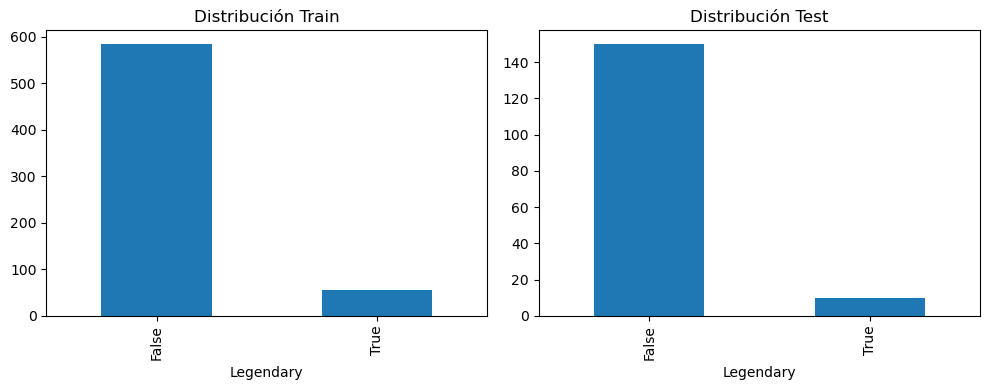

In [31]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

y_train.value_counts().plot(kind='bar', ax=axes[0], title='Distribución Train')
y_test.value_counts().plot(kind='bar', ax=axes[1], title='Distribución Test')

plt.tight_layout()
plt.show()

### Definición del modelo  
Defina al menos 3 arquitecturas de redes neuronales simples (MLP) para el problema de clasificación. Justifique las decisiones que tome en la definición de cada arquitectura. Las definiciones se deben hacer en un archivo ```models.py``` e importarlas en este cuadernillo. Debe seleccionar "la mejor" arquitectura para el entrenamiento, y justificar su elección.

In [32]:
from models import MultiLayerPerceptronSig,MultiLayerPerceptronRelu, MultiLayerPerceptron2Cap
## se elige el valor input = 6 ya que hay 6 columnas utiles
modelo1 = MultiLayerPerceptronSig(input_dim=6, output_dim=2, hidden_dim=16)
modelo2 = MultiLayerPerceptron2Cap(input_dim=6, output_dim=2, hidden_dim=16) ## se eligen más nodos ocultos 
modelo3 = MultiLayerPerceptronRelu(input_dim=6, output_dim=2, hidden_dim=8,dropout_p=0.2) ## se prueba con funcion de activación relu

In [33]:
modelo1.hidden.weight, modelo1.hidden.bias, modelo1.output.weight, modelo1.output.bias

(Parameter containing:
 tensor([[-0.2295, -0.0925,  0.3643,  0.2288,  0.2852,  0.1246],
         [ 0.1444,  0.1000,  0.3894,  0.0837, -0.3476,  0.3173],
         [-0.1618,  0.0779,  0.1748,  0.2087, -0.1818, -0.3168],
         [ 0.3466, -0.2300,  0.3010,  0.1900,  0.3374, -0.1987],
         [-0.1120, -0.0378,  0.1962,  0.3264,  0.3074,  0.1720],
         [ 0.2215,  0.1741,  0.0864,  0.3627,  0.2106, -0.1978],
         [ 0.2359,  0.2162, -0.1708,  0.0176, -0.2914, -0.1054],
         [-0.0917, -0.1472,  0.0004, -0.1131, -0.0924, -0.3528],
         [-0.2582, -0.0059, -0.0033,  0.1545, -0.0175, -0.1877],
         [-0.1022,  0.2495, -0.0680,  0.3146, -0.2670,  0.1858],
         [-0.2200,  0.1353, -0.2451,  0.1189,  0.1176, -0.2396],
         [ 0.3775,  0.2549, -0.3035, -0.2218, -0.1713, -0.4033],
         [-0.0406, -0.3359,  0.1607, -0.2522, -0.4063,  0.1644],
         [-0.1348, -0.3454,  0.1684, -0.3822, -0.1229, -0.3843],
         [ 0.3276, -0.0519, -0.1299, -0.3468, -0.0247,  0.0953],
  

*Justificación*: Es elegida como un modelo simple de referencia. Al tener solo una capa oculta, minimizamos el riesgo de overfitting, aspecto importante ya que el dataset de Pokémon no es muy grande. La función de activación Sigmoide introduce la no linealidad necesaria para que el modelo pueda aprender patrones complejos en los datos, lo que es crucial para una tarea de clasificación binaria como esta. Además, al ser un modelo más sencillo, es más fácil de interpretar y analizar, lo que puede ser beneficioso para entender cómo se están tomando las decisiones en la clasificación de los Pokemon como legendarios o no legendarios.

In [34]:
#modelo2.hidden.weight, modelo2.hidden.bias, modelo2.output.weight, modelo2.output.bias

*Justificación*: Similar a arquitectura anterior en cuanto a tamaño y capacidad para prevenir overfitting, pero añadiendo ReLU. ReLU mitiga el problema de la desaparición del gradiente y su cálculo computacional es más eficiente. En la práctica, tiene una convergencia mucho más rápida y es más robusta estadisticamente ante valores escalados numéricamente.

In [35]:
modelo3.hidden.weight, modelo3.hidden.bias, modelo3.output.weight, modelo3.output.bias

(Parameter containing:
 tensor([[-0.1155,  0.2984,  0.2288, -0.2623, -0.0542,  0.3672],
         [ 0.0294,  0.0644, -0.2805, -0.3954,  0.2725,  0.1577],
         [-0.0933, -0.2314, -0.1181, -0.2316, -0.3822, -0.3904],
         [-0.0702,  0.2519,  0.0631, -0.0952, -0.1150,  0.1275],
         [ 0.1401,  0.2717,  0.3949,  0.3050, -0.2548, -0.0833],
         [-0.0272,  0.3006, -0.0955,  0.0412, -0.1353, -0.2893],
         [ 0.1284, -0.3238,  0.2595,  0.3934, -0.2488, -0.1168],
         [-0.2739, -0.0461,  0.1083,  0.2742, -0.1186, -0.2438]],
        requires_grad=True),
 Parameter containing:
 tensor([-0.2347, -0.2485,  0.0784,  0.2735,  0.2369,  0.3992, -0.1995, -0.3491],
        requires_grad=True),
 Parameter containing:
 tensor([[ 0.3199,  0.1100,  0.3067,  0.0819, -0.2111, -0.0921,  0.2022, -0.3092],
         [-0.2806,  0.2864, -0.3525, -0.3187,  0.1563, -0.0271, -0.0565, -0.2870]],
        requires_grad=True),
 Parameter containing:
 tensor([-0.0207, -0.3161], requires_grad=True))

*Justificación*: Propuesta para explorar si el problema de clasificación requiere extracción de características jerárquicamente complejas. Al tener más profundidad, permite encontrar relaciones no lineales más profundas entre las distintas estadísticas de los Pokémon. Ayuda a probar si es que una red más profunda mejora las predicciones o si, por el contrario, perjudica al modelo haciendo overfitting a los datos de entrenamiento. 

*Decisión de la mejor*: Para poder clasificar a un Pokémon, basándonos en sus atributos, es necesario elegir un modelo que facilite la elección y que no memorice los datos, ya que la clase "Legendario" es una minoría dentro del dataset y, este mismo, es relativamente pequeño. Por esta razón, la arquitectura seleccionada será; MultiLayerPerceptronRelu (Arquitectura 3).

Si hablamos de simplicidad y complejidad, la arquitectura elegida al limitarse a una sola capa oculta, la red cuenta con los parámetros justos para encontrar la barrera de decisión (tener estadísticas por sobre la media por ejemplo) sin caer en el overfitting que podría provocar una arquitectura de dos capas (como la arquitectura 2).

Si hablamos de entrenamiento, ReLu permite propagar mejor los gradientes en comparación a la función Sigmoide. Esto provoca que el modelo pueda actualizar sus pesos con pasos más confiables y eficientes, llegando al óptimo más rápido que el modelo de la arquitectura 1.

### Definición de optimizador y función de costo  
Defina un optimizador y una función de costo adecuado para el entrenamiento del modelo. Justifique sus decisiones.

In [36]:
## Funcion de costo CrossEntropyLoss -> ya que esta sirve para problemas de clasificación
criterion = nn.CrossEntropyLoss()

In [37]:
## Optimizador
optimizer = torch.optim.Adam(modelo3.parameters(), lr=1e-2, weight_decay=1e-3)

*Justificación*: 
Para la Función de costo (CrossEntropyLoss):  
Elegimos esta función porque es el estándar para problemas de clasificación donde queremos separar elementos en categorías definidas (en nuestro caso, "Legendario" o "No Legendario"). En PyTorch, esta función es muy conveniente porque hace dos trabajos a la vez: convierte las predicciones puras del modelo en probabilidades y luego calcula el error. Al hacer esto en un solo paso interno, evita errores matemáticos haciendo que el entrenamiento sea numéricamente más estable. Además, es excelente para que el modelo aprenda rápido, ya que lo "castiga" de forma más severa si comete un error estando muy seguro de su respuesta incorrecta.

Para el Optimizador (Adam con un learning rate base de 0.001):
Elegimos Adam porque es uno de los métodos más confiables y eficientes en la actualidad. Su principal ventaja es que adapta automáticamente la forma en que el modelo aprende, guiándose por la "inercia" de sus pasos anteriores para no estancarse. Dado el tamaño de nuestro dataset, esto ayuda a que la red encuentre la solución correcta mucho más rápido y sin tener que ajustar tantas configuraciones de forma manual, a diferencia de los algoritmos más clásicos. Además, le definimos una tasa de aprendizaje (learning rate) de 0.001, que funciona como un equilibrio ideal: los "pasos" que da para aprender son lo suficientemente grandes para avanzar a buen ritmo, pero no tan exagerados como para "pasar de largo" la solución correcta y volverse inestable.

### Entrenamiento del modelo
Entrene el modelo seleccionado utilizando el dataset preparado. Justifique las decisiones que tome en el proceso de entrenamiento, incluyendo la selección de hiperparámetros, el número de épocas, el tamaño del batch, etc.

In [38]:
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split

# --- Primero divide X_train en train + validación (80/20 del train original) ---
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train_tensor, y_train_tensor,
    test_size=0.2,
    random_state=42,
    stratify=y_train_tensor 
)


# Verifica que la proporción sea similar en ambos
print(f"% legendarios en train: {y_tr.float().mean()*100:.1f}%")
print(f"% legendarios en valid: {y_val.float().mean()*100:.1f}%")

# --- Loaders ---
train_dataset = TensorDataset(X_tr, y_tr)
valid_dataset = TensorDataset(X_val, y_val)
test_dataset  = TensorDataset(X_test_tensor, y_test_tensor)

# Con un dataset tan pequeño, puedes usar batch_size = tamaño total
train_loader = DataLoader(train_dataset, batch_size=len(train_dataset), shuffle=True)
valid_loader = DataLoader(valid_dataset, batch_size=len(valid_dataset), shuffle=False)
test_loader  = DataLoader(test_dataset,  batch_size=len(valid_dataset), shuffle=False)

print(f"\nTrain: {len(train_dataset)} | Valid: {len(valid_dataset)} | Test: {len(test_dataset)}")

% legendarios en train: 8.6%
% legendarios en valid: 8.6%

Train: 512 | Valid: 128 | Test: 160


In [39]:
import numpy as np

def update_step(data, label):
    """Recibe un minibatch y actualiza los parámetros del modelo"""
    # Forzar el tipo de dato correcto para clasificación
    label = label.long().squeeze()
    
    # Forward pass
    prediction = modelo3(data)
    
    # Limpieza y retropropagación de gradientes
    optimizer.zero_grad()
    loss = criterion(prediction, label)
    loss.backward()
    
    # Actualización de pesos
    optimizer.step()
    return loss.item()

def evaluate_step(data, label):
    """Recibe un minibatch y evalúa el criterio de optimización sin gradientes"""
    label = label.long().squeeze()
    prediction = modelo3(data)
    loss = criterion(prediction, label)
    return loss.item()

def train_one_epoch(epoch):
    """Realiza una época completa de entrenamiento y validación"""
    train_loss, valid_loss = 0.0, 0.0
    
    # Fase de Entrenamiento
    modelo3.train()
    for batchx, batchy in train_loader:
        train_loss += update_step(batchx, batchy)
        
    # Fase de Validación
    modelo3.eval()
    with torch.no_grad():
        for batchx, batchy in valid_loader:
            valid_loss += evaluate_step(batchx, batchy)
    # Guardar modelo si es el mejor hasta ahora
    global best_valid_loss
    if epoch % 10 == 0:
        if valid_loss < best_valid_loss:
            best_valid_loss = valid_loss
            torch.save({'epoca': epoch,
                        'model_state_dict': modelo3.state_dict(),
                        'optimizer_state_dict': optimizer.state_dict(),
                        'loss': valid_loss}, 
                       'best_model.pt')
    # Retorna las pérdidas promedio de la época actual
    return train_loss / len(train_loader), valid_loss / len(valid_loader)

Época [100/1000] | Train Loss: 0.1046 | Val Loss: 0.1510
Época [200/1000] | Train Loss: 0.0868 | Val Loss: 0.1371
Época [300/1000] | Train Loss: 0.0897 | Val Loss: 0.1496
Época [400/1000] | Train Loss: 0.0852 | Val Loss: 0.1462
Época [500/1000] | Train Loss: 0.0863 | Val Loss: 0.1470
Época [600/1000] | Train Loss: 0.0843 | Val Loss: 0.1472
Época [700/1000] | Train Loss: 0.0841 | Val Loss: 0.1472
Época [800/1000] | Train Loss: 0.0795 | Val Loss: 0.1472
Época [900/1000] | Train Loss: 0.0802 | Val Loss: 0.1472
Época [1000/1000] | Train Loss: 0.0859 | Val Loss: 0.1472


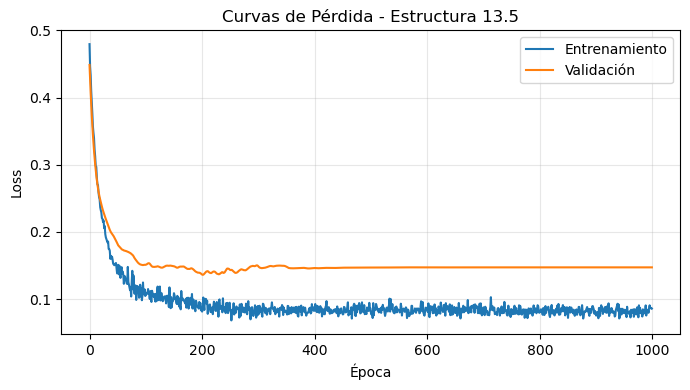

In [40]:
# Definición de épocas y asignación del contenedor matricial de NumPy
num_epochs = 1000
running_loss = np.zeros(shape=(num_epochs, 2)) 
best_valid_loss = np.inf 

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=50
)

for epoch in range(num_epochs):
    # Ejecuta la época y guarda la tupla de pérdidas en la fila correspondiente
    running_loss[epoch] = train_one_epoch(epoch) 
    scheduler.step(running_loss[epoch, 1])
    # Monitoreo en consola cada 100 épocas
    if (epoch + 1) % 100 == 0:
        print(f"Época [{epoch+1}/{num_epochs}] | "
            f"Train Loss: {running_loss[epoch, 0]:.4f} | "
            f"Val Loss: {running_loss[epoch, 1]:.4f}")
# ========== GENERACIÓN DEL GRÁFICO ==========
# Extracción de columnas desde la matriz running_loss
fig, ax = plt.subplots(figsize=(7, 4), tight_layout=True) 
ax.plot(running_loss[:, 0], label='Entrenamiento') 
ax.plot(running_loss[:, 1], label='Validación') 
ax.set_xlabel('Época') 
ax.set_ylabel('Loss') 
#ax.set_yscale('log')  # <-- AGREGAR ESTO
ax.legend() 
ax.grid(True, alpha=0.3)
plt.title("Curvas de Pérdida - Estructura 13.5")
plt.show()

In [41]:
saved_model = torch.load('best_model.pt')

In [42]:
# codigo para cargar el modelo y obtener los FP y FN
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# Reproducir exactamente el mismo split
data = pd.read_csv("Pokemon.csv")
features = ['HP', 'Attack', 'Defense', 'Sp. Atk', 'Sp. Def', 'Speed']
X = data[features]
y = data['Legendary']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

# Cargar el mejor modelo
checkpoint = torch.load('best_model.pt')
modelo3.load_state_dict(checkpoint['model_state_dict'])
modelo3.eval()

# Inferencia
X_test_tensor = torch.FloatTensor(X_test)
with torch.no_grad():
    predicciones = modelo3(X_test_tensor)
    clases_predichas = torch.argmax(predicciones, dim=1).numpy()

# Armar dataframe con resultados
test_data = data.loc[y_test.index].copy()
test_data['Real'] = y_test.values.astype(int)
test_data['Predicho'] = clases_predichas

# Filtrar mal clasificados
FP = test_data[(test_data['Real'] == 0) & (test_data['Predicho'] == 1)]
FN = test_data[(test_data['Real'] == 1) & (test_data['Predicho'] == 0)]

print("=== FP: Normales clasificados como Legendarios ===")
print(FP[['Name', 'HP', 'Attack', 'Defense', 'Sp. Atk', 'Sp. Def', 'Speed', 'Total']])

print("\n=== FN: Legendarios clasificados como Normales ===")
print(FN[['Name', 'HP', 'Attack', 'Defense', 'Sp. Atk', 'Sp. Def', 'Speed', 'Total']])

=== FP: Normales clasificados como Legendarios ===
                          Name   HP  Attack  Defense  Sp. Atk  Sp. Def  Speed  \
696                  Hydreigon   92     105       90      125       90     98   
275      SceptileMega Sceptile   70     110       75      145       85    145   
715         MeloettaAria Forme  100      77       77      128      128     90   
409    SalamenceMega Salamence   95     145      130      120       90    120   
7    CharizardMega Charizard X   78     130      111      130       85    100   
776                     Goodra   90     100       70      110      150     80   

     Total  
696    600  
275    630  
715    600  
409    700  
7      634  
776    600  

=== FN: Legendarios clasificados como Normales ===
        Name   HP  Attack  Defense  Sp. Atk  Sp. Def  Speed  Total
423  Groudon  100     150      140      100       90     90    670
795  Diancie   50     100      150      100      150     50    600
537     Uxie   75      75      130   

### Evaluación del modelo
Evalúe el modelo utilizando métricas adecuadas para este problema de clasificación. Justifique la selección de las métricas utilizadas y discuta los resultados obtenidos. 

--- REPORTE DE CLASIFICACIÓN ---
               precision    recall  f1-score   support

No Legendario       0.98      0.96      0.97       150
   Legendario       0.54      0.70      0.61        10

     accuracy                           0.94       160
    macro avg       0.76      0.83      0.79       160
 weighted avg       0.95      0.94      0.95       160



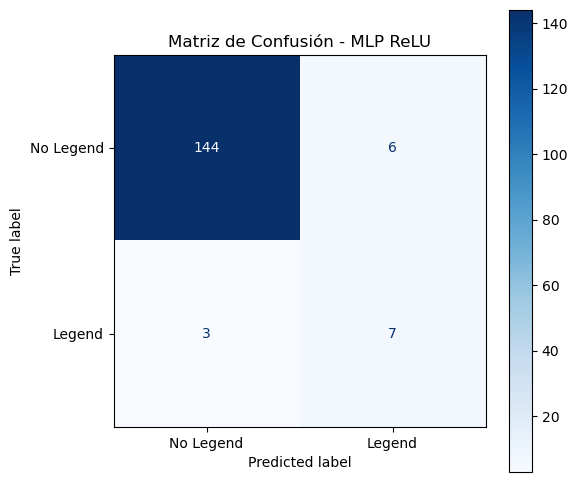

In [43]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay

# 1. Poner el modelo en modo evaluación
modelo3.eval()

# Listas vacías para guardar las predicciones del modelo y las etiquetas reales
y_pred_list = []
y_true_list = []

# 2. Desactivar el cálculo de gradientes
with torch.no_grad():
    for batch_X, batch_y in test_loader:
        # Asegurarnos del formato correcto de las etiquetas (igual que en entrenamiento)
        batch_y = batch_y.long().squeeze()
        
        # a. Hacer la predicción (Forward)
        predicciones = modelo3(batch_X)
        
        # b. Obtener la clase predicha (0 o 1)
        # Las predicciones salen como dos probabilidades [prob_no_legend, prob_legend]
        # argmax(dim=1) elige el índice del valor más alto
        clases_predichas = torch.argmax(predicciones, dim=1)
        
        # c. Guardar los resultados pasándolos de tensores a listas de numpy
        y_pred_list.extend(clases_predichas.cpu().numpy())
        y_true_list.extend(batch_y.cpu().numpy())

# 3. Mostrar el Reporte de Clasificación (Aquí está el F1-Score)
print("--- REPORTE DE CLASIFICACIÓN ---")
print(classification_report(y_true_list, y_pred_list, target_names=['No Legendario', 'Legendario']))

# 4. Generar y visualizar la Matriz de Confusión
cm = confusion_matrix(y_true_list, y_pred_list)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Legend', 'Legend'])

fig, ax = plt.subplots(figsize=(6, 6))
disp.plot(cmap=plt.cm.Blues, ax=ax)
plt.title("Matriz de Confusión - MLP ReLU")
plt.show()

### Preguntas finales
1. Sobre la matriz de confusión, interprete los resultados obtenidos. Con sus palabras defina que significa cada tipo de error. ¿Elegiría a Pokémon ubicados en FP o FN para su equipo?
144 TN: No legendarios correctamente clasificados
7 TP: Legendarios correctamente identificados
6 FP: El modelo dijo "Legendario" pero no lo eran. El error es tratar como especial a un Pokémon común que tiene stats muy elevadas (ej: Mega Salamence con 700 de total, más que varios verdaderos legendarios).
3 FN: El modelo dijo "No Legendario" pero sí lo eran (Groudon, Diancie, Uxie). El error opuesto: legendarios que "se ven" normales en sus stats y pasaron desapercibidos.

Elegiría los Pokémon ubicados en FP ya que son Pokémon no legendarios con estadísticas tan altas que engañaron al modelo. En competitivo eso es ideal, porque en formatos donde los legendarios están prohibidos, igual habría un Mega Salamence de 700 stats en el equipo.

2. Busque un caso mal clasificado por el modelo, e interprete por qué cree que el modelo se equivocó en ese caso.
Un caso mal clasificado es de los FN (legendaria clasificada como normal), específicamente, Diancie. Tiene 600 de total, pero su distribución de stats es muy peculiar: HP=50, Ataque=100, Defensa=150, Sp.Atk=100, Sp.Def=150, Speed=50. Su HP y velocidad son extremadamente bajos (50), estadísticas que el modelo asocia a Pokémon comunes débiles. El modelo aprendió que los legendarios suelen ser poderosos en todas sus dimensiones, y Diancie tiene dos stats por debajo de la media, lo que confundió la decisión del clasificador.

3. ¿Cúal fue el mayor desafío que enfrentó al realizar esta tarea? ¿Cómo lo solucionó?
El mayor desafío enfrentado al momento de realizar la tarea fue calibrar la red neuronal para llegar al resultado correcto y evitar el overfitting excesivo y bugs de validación (sobretodo relacionado al gráfico de convergencia, para que quede lo más parecido posible a una correcta convergencia entre entrenamiento y validación). Se pivotó entre el número de neuronas del modelo, learning rate, weight decay, batch size, número de épocas y porcentaje de dropout. Además, durante el procedimiento se fue probando entre gráficos escalados logaritmicamente y no escalados para una visualización más adecuada y entendible a la vista. 
Durante el proceso de entrenamiento, se fueron adaptando nuevas metodologías de entrenamiento, por ejemplo, se implementó dropout y la variable de weight decay. Variables claves para el desarrollo del modelo porque sin el valor de estas no se habría obtenido un resultado acertado.  



### IA Generativa

Con el fin de ocupar IA Generativa de manera responsable, se les pide que respondan a las siguientes preguntas:
1. ¿Utilizó alguna herramienta de IA Generativa para realizar esta tarea? En caso afirmativo, indique cuál o cuáles herramientas utilizó.

R: Se utilizó copilot, modelo Claude Haiku 4.5 unicamente para refactorizar markdown


2. ¿En qué parte o partes de la tarea utilizó estas herramientas?